In [ ]:
# Define learn function
# num_params is the number of parameters. Ex cubic function is 4 (3 coefficients plus a bias)
def learn(alpha, num_epoch, num_params, x_train, y_train):
    weight_history = []
    error_history = []
    weights = np.array([np.random.random() / 10] * num_params) # seed the weights

    j = 0

    while j < num_epoch:
        x_j_input = x_train[j % len(x_train)] # Single input
        input_j = np.array([x_j_input ** i for i in range(num_params)]) # Use 1 as the x input val for bias

        # Calculate sum of loss
        loss_sum = 0
        for n in range(len(x_train)):
            weighted_input_n = np.array([weights[i] * x_train[n] ** i for i in range(num_params)]) 
            input_n = np.array([x_train[n] ** i for i in range(num_params)]) 
            pred_val = np.sum(weighted_input_n) 
            loss = (y_train[n] - pred_val) * input_n # A vector of loss for each parameter (weight and bias)
            loss_sum = loss_sum + loss

        error_history.append(np.sum(loss_sum))
        # Update theta
        weights = weights + alpha * loss_sum
        weight_history.append(weights)

        j = j + 1
    
    return weights, weight_history, error_history, loss_sum


# Part 2

## Status: working on loading CSVs correctly, then planning on running "learn" function on one to get it to work, then find a way to return a predicted error or other metric and run on all in loop, and pick the best fit one

In [106]:
import matplotlib.pyplot as plt
import numpy as np

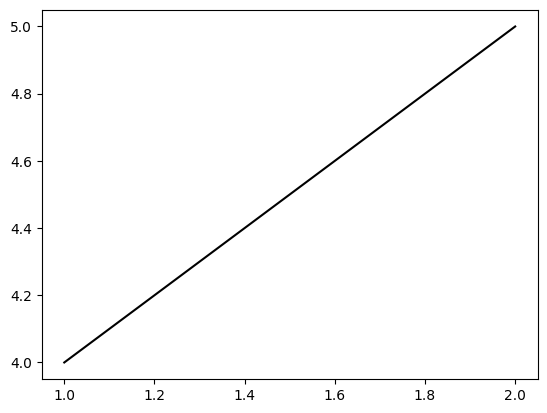

In [107]:

first_x = 1
last_x = 2
bias = 3
learned_slope = 1
plt.plot([first_x, last_x], [bias + first_x * learned_slope, bias + last_x * learned_slope], color="black")
plt.show()

In [108]:
data_formats = {'names': ('id', 'baths', 'land', 'living', 'garages', 'rooms','beds','age', 'price'), 'formats':('i2', 'f2', 'f4','f4', 'f4', 'i4', 'i4','i4','f8')}
housing_train = np.loadtxt("train.csv", delimiter=',', skiprows=1, dtype=data_formats)
housing_test = np.loadtxt("test.csv", delimiter=',', skiprows=1, dtype=data_formats)
#House ID,Bathrooms,Land Area,Living area,# Garages,# Rooms,# Bedrooms,Age of home,Price

housing_train_output = housing_train["price"]

for n in data_formats["names"]:
    if n == 'price':
        continue
    print("\n\n", n)
    housing_train_input = housing_train[n]

    learned_slope, bias, slope_history, bias_history, error_history, final_loss = learn(200, housing_train_input, housing_train_output)
    print(f"Learned slope: {learned_slope}")
    print(f"Learned bias: {bias}")
    print(f"Equation: h(x) = {learned_slope}x + {bias}")
    print(f"Loss is {final_loss}")

    plt.scatter(housing_train_input, housing_train_output)
    first_x = np.min(housing_train_input)
    last_x = np.max(housing_train_input)
    plt.plot([first_x, last_x], [bias - first_x * learned_slope, bias + last_x * learned_slope], color="black")
    plt.title(f"Price vs {n}")
    plt.show()



 id


TypeError: learn() missing 1 required positional argument: 'y_train'